<a href="https://www.kaggle.com/code/lalit7881/ndonesia-airbnb-dataset-bandung-eda?scriptVersionId=341756625" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/pandaa12/indonesia-airbnb-dataset-bandung-listings/AirBnB_BandungRaya_All.csv
/kaggle/input/datasets/pandaa12/indonesia-airbnb-dataset-bandung-listings/AirBnB_Kota_Bandung.csv
/kaggle/input/datasets/pandaa12/indonesia-airbnb-dataset-bandung-listings/AirBnb_Kab_Bandung_Barat.csv
/kaggle/input/datasets/pandaa12/indonesia-airbnb-dataset-bandung-listings/AirBnb_Kab_Bandung.csv
/kaggle/input/datasets/pandaa12/indonesia-airbnb-dataset-bandung-listings/AirBnB_Kota_Cimahi.csv


## Loading dataset

In [2]:
# Imports and Setup
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')  # Ensure matplotlib uses the non-interactive backend
import matplotlib.pyplot as plt
plt.switch_backend('Agg')  # If only plt imported
%matplotlib inline

import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

from pathlib import Path

# Helper to resolve data file paths
DATA_ROOTS = [
    Path('/kaggle/input'),
    Path('/kaggle/input'),
    Path('/kaggle/input/datasets'),
]

def resolve_data_file(file_name=None, suffixes=None):
    suffixes = tuple(suffixes or [])
    for root in DATA_ROOTS:
        if not root.exists():
            continue
        matches = [p for p in root.rglob('*') if p.is_file()]
        if file_name:
            exact = [p for p in matches if p.name == file_name]
            if exact:
                return exact[0]
        if suffixes:
            typed = [p for p in matches if p.suffix.lower() in suffixes]
            if typed:
                return typed[0]
    raise FileNotFoundError(f'Could not resolve data file: {file_name or suffixes}')

# Set seaborn style
sns.set(style='whitegrid')

In [3]:
file_names = [
    'AirBnB_BandungRaya_All.csv',
    'AirBnb_Kab_Bandung.csv',
    'AirBnB_Kota_Cimahi.csv',
    'AirBnB_Kota_Bandung.csv',
    'AirBnb_Kab_Bandung_Barat.csv'
]

data_frames = []
for file in file_names:
    try:
        file_path = resolve_data_file(file_name=file, suffixes=['.csv'])
        # Note: The files are encoded in UTF-8-SIG and use a comma as the delimiter
        df_temp = pd.read_csv(file_path, encoding='UTF-8-SIG', delimiter=',')
        data_frames.append(df_temp)
    except Exception as e:
        print(f'Error loading {file}:', e)

# Combine all datasets
df = pd.concat(data_frames, ignore_index=True)
print('Combined dataset shape:', df.shape)

Combined dataset shape: (1361, 6)


In [4]:
print('Original DataFrame columns:', df.columns.tolist())

# Cleaning the 'harga' column:
# The 'harga' column is a string that likely contains currency symbols and formatting.
def clean_price(price_str):
    try:
        # Remove common currency symbols and thousand separators
        price_str = str(price_str).replace('Rp', '').replace('.', '').replace(',', '').strip()
        return int(price_str)
    except Exception:
        return np.nan

df['harga_clean'] = df['harga'].apply(clean_price)

# Convert rating to numeric. Some ratings might not be proper floats, so we use pd.to_numeric
df['rating_numeric'] = pd.to_numeric(df['rating'], errors='coerce')

# It might be helpful to drop rows with missing critical values
df.dropna(subset=['harga_clean', 'rating_numeric', 'jumlah_review'], inplace=True)

# Reset index after dropping rows
df.reset_index(drop=True, inplace=True)

print('DataFrame shape after cleaning:', df.shape)
print(df.head())

Original DataFrame columns: ['nama', 'harga', 'rating', 'jumlah_review', 'link', 'wilayah']
DataFrame shape after cleaning: (1244, 8)
                                                nama          harga rating  \
0  Home in Cibeunying Kaler - Serene Pet-Friendly...   Rp 9,848,899    5.0   
1  Apartment in Cidadap - Dago, Ciumbuleuit, ITB ...   Rp 3,446,781   4.98   
2         Home in Sukajadi - Pine Breeze W/ Backyard  Rp 12,500,000   4.95   
3  Apartment in Cidadap - Abony | Bandung | PVJ |...   Rp 2,054,119   4.87   
4                     Home in Cidadap - Wangiterrace   Rp 9,883,877   4.98   

   jumlah_review                                              link  \
0             33  https://www.airbnb.com/rooms/1647712818622104523   
1            132  https://www.airbnb.com/rooms/1583745571091269827   
2            112  https://www.airbnb.com/rooms/1400529902543354123   
3             38  https://www.airbnb.com/rooms/1496783488914922824   
4             51  https://www.airbnb.com/rooms/

In [5]:
print('Descriptive statistics for numeric columns:')
print(df[['harga_clean', 'rating_numeric', 'jumlah_review']].describe())


Descriptive statistics for numeric columns:
        harga_clean  rating_numeric  jumlah_review
count  1.244000e+03     1244.000000    1244.000000
mean   9.288274e+06        4.902275      76.835209
std    9.311385e+06        0.108443      95.064306
min    1.000000e+06        4.290000       3.000000
25%    3.636326e+06        4.860000      17.000000
50%    6.991250e+06        4.930000      41.000000
75%    1.109141e+07        4.990000      98.000000
max    9.400000e+07        5.000000     822.000000


In [6]:
print('\nMissing values in each column:')
print(df.isnull().sum())


Missing values in each column:
nama              0
harga             0
rating            0
jumlah_review     0
link              0
wilayah           0
harga_clean       0
rating_numeric    0
dtype: int64


In [7]:
print('\nUnique wilayah values:')
print(df['wilayah'].unique())


Unique wilayah values:
['Kota Bandung' 'Kota Cimahi' 'Kabupaten Bandung'
 'Kabupaten Bandung Barat']


## EDA

Text(0.5, 1.0, 'Distribution of Harga (Cleaned)')

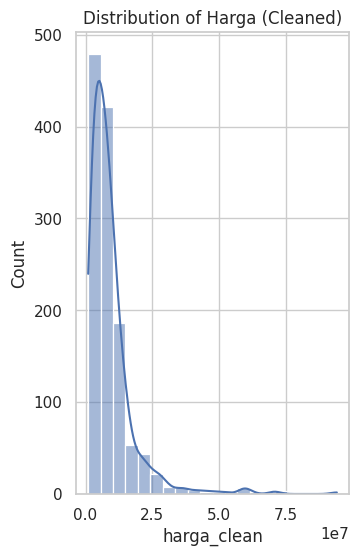

In [8]:
# Visualizations
plt.figure(figsize=(12, 6))

# 1. Histogram for price (harga_clean)
plt.subplot(1, 3, 1)
sns.histplot(df['harga_clean'], bins=20, kde=True)
plt.title('Distribution of Harga (Cleaned)')

Text(0.5, 1.0, 'Distribution of Rating')

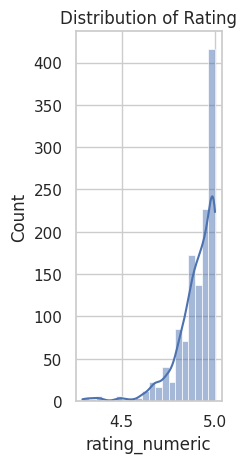

In [9]:
# 2. Histogram for rating
plt.subplot(1, 3, 2)
sns.histplot(df['rating_numeric'], bins=20, kde=True)
plt.title('Distribution of Rating')

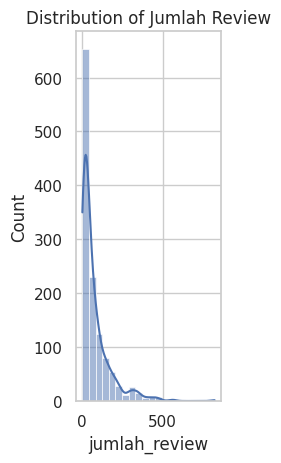

In [10]:
# 3. Histogram for jumlah_review
plt.subplot(1, 3, 3)
sns.histplot(df['jumlah_review'], bins=20, kde=True)
plt.title('Distribution of Jumlah Review')

plt.tight_layout()
plt.show()

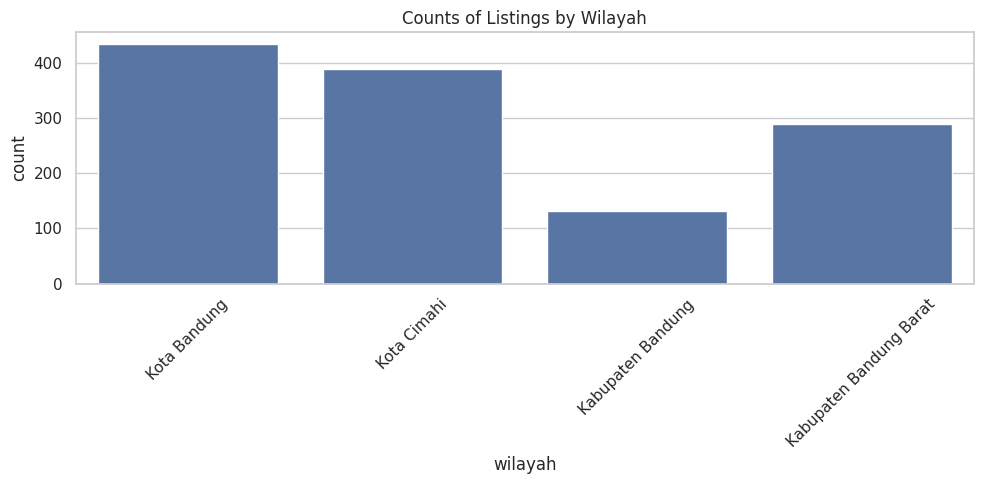

In [11]:
# Count Plot for categorical 'wilayah'
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='wilayah')
plt.title('Counts of Listings by Wilayah')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

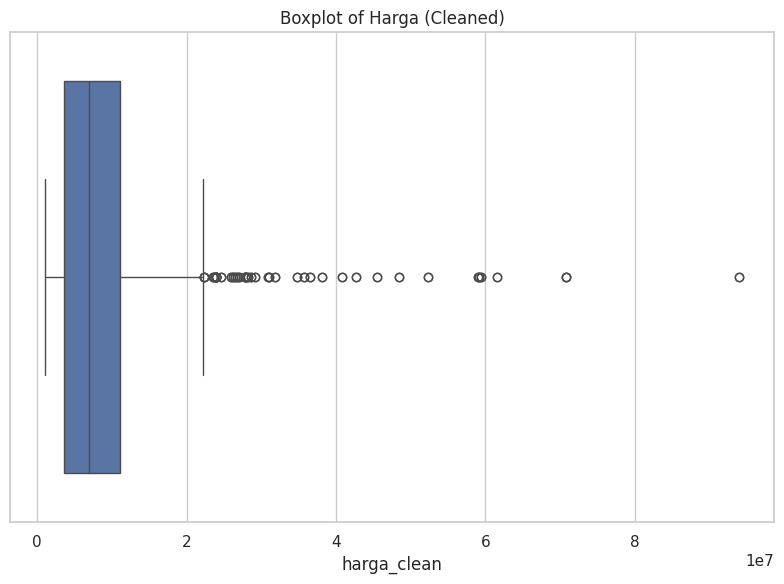

In [12]:
# Box Plot for Harga
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['harga_clean'])
plt.title('Boxplot of Harga (Cleaned)')
plt.tight_layout()
plt.show()


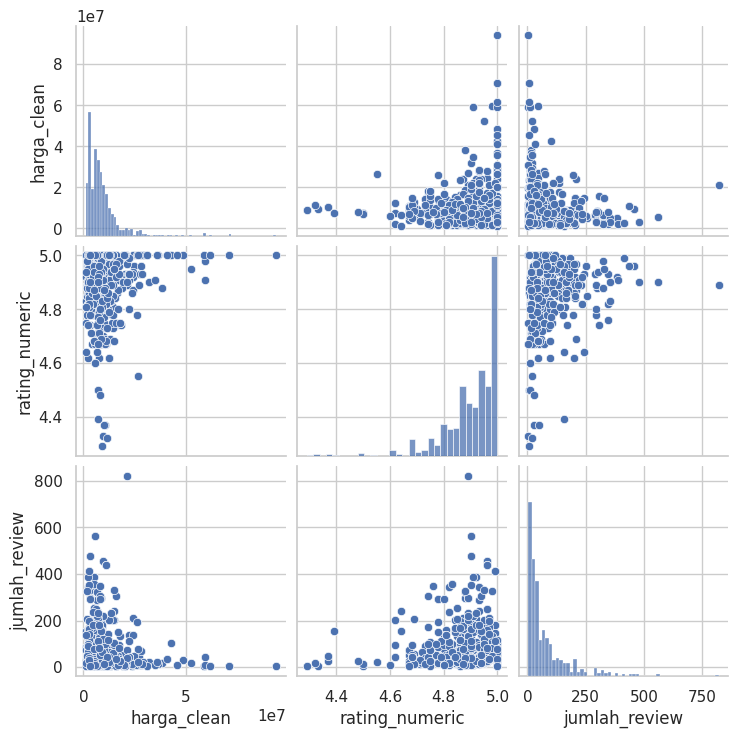

In [13]:
# Pair Plot for numeric features
numeric_df = df[['harga_clean', 'rating_numeric', 'jumlah_review']]
sns.pairplot(numeric_df)
plt.show()


## Feature engineering

In [14]:
# Define features and target
features = ['harga_clean', 'jumlah_review']
target = 'rating_numeric'

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(df[features], df[target], test_size=0.2, random_state=42)

# Initialize and train a simple Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict on the test set
y_pred = lr_model.predict(X_test)

# Calculate the R^2 score as an accuracy metric
score = r2_score(y_test, y_pred)
print('Linear Regression R^2 Score:', score)

# For transparency, display the coefficients
print('Model Coefficients:', lr_model.coef_)
print('Model Intercept:', lr_model.intercept_)

Linear Regression R^2 Score: -0.003065972327121802
Model Coefficients: [ 8.59869683e-10 -8.41007429e-05]
Model Intercept: 4.898525605229328


## Thank you..pls upvote!!!!!!!!!!!!